# Cross-language direction alignment

Per-layer cosine similarity between the **`combined_vs_neutral_en`** and **`combined_vs_neutral_tl`** mean-difference directions.

In [1]:
from pathlib import Path

import torch
from safetensors import safe_open


def find_directions_dir():
    """Locate data/directions/ regardless of the notebook's working directory."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "data" / "directions"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError("could not locate data/directions")


DIRECTIONS_DIR = find_directions_dir()


def load_direction(name, key="direction"):
    path = DIRECTIONS_DIR / name / "directions.safetensors"
    with safe_open(str(path), framework="pt") as f:
        return f.get_tensor(key).float()      # [num_layers + 1, hidden_dim]


en = load_direction("combined_vs_neutral_en")
tl = load_direction("combined_vs_neutral_tl")
assert en.shape == tl.shape, (en.shape, tl.shape)

In [2]:
# Per-layer cosine similarity. Index 0 = embeddings; 1..num_layers = transformer blocks.
cosine = torch.nn.functional.cosine_similarity(en, tl, dim=1)   # [num_layers + 1]
layers = list(range(en.shape[0]))

print(f"directions: {DIRECTIONS_DIR}")
print(f"shape per direction: {tuple(en.shape)}")
print(f"cosine  min={cosine.min():.3f}  mean={cosine.mean():.3f}  max={cosine.max():.3f}  "
      f"(peak at layer {int(cosine.argmax())})")

directions: c:\Users\Arnel Malubay\Documents\Projects\apart-global-south-persuasion-project\data\directions
shape per direction: (36, 1536)
cosine  min=0.418  mean=0.657  max=0.805  (peak at layer 15)


In [3]:
cosine

tensor([0.5339, 0.4690, 0.5402, 0.6136, 0.6993, 0.6815, 0.7103, 0.7153, 0.7439,
        0.7503, 0.6847, 0.7416, 0.7311, 0.7722, 0.7966, 0.8052, 0.7999, 0.7860,
        0.8007, 0.7970, 0.7793, 0.7177, 0.6440, 0.6336, 0.6882, 0.7214, 0.6934,
        0.6630, 0.6319, 0.6128, 0.5049, 0.4501, 0.4201, 0.4184, 0.4601, 0.4505])

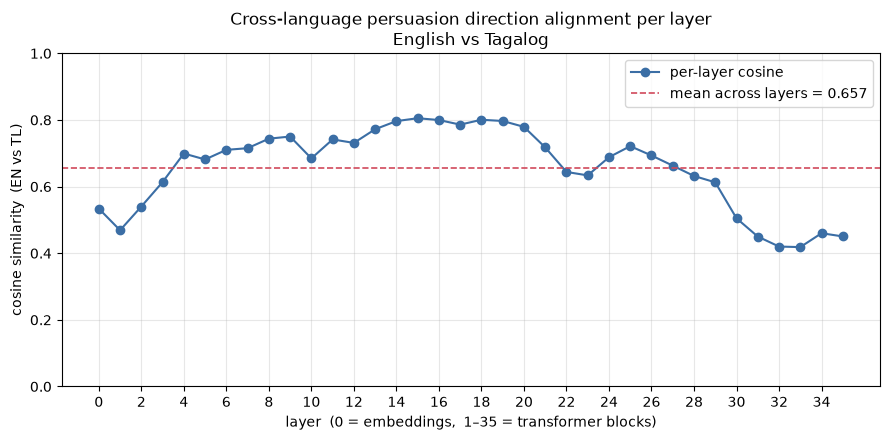

In [6]:
import matplotlib.pyplot as plt

mean_cos = cosine.mean().item()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(layers, cosine.tolist(), marker="o", color="#3b6ea5", label="per-layer cosine")
ax.axhline(mean_cos, color="#d1495b", lw=1.2, ls="--",
           label=f"mean across layers = {mean_cos:.3f}")
ax.set_xlabel("layer  (0 = embeddings,  1–35 = transformer blocks)")
ax.set_ylabel("cosine similarity  (EN vs TL)")
ax.set_title("Cross-language persuasion direction alignment per layer\n"
             "English vs Tagalog")
ax.set_ylim(0.0, 1.0)
ax.set_xticks(range(0, len(layers), 2))
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()